In [ ]:
!pip -q install praw newsapi-python pandas numpy matplotlib seaborn nltk scikit-learn wordcloud

!pip install feedparser newsapi-python nltk pandas numpy matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 189.3/189.3 kB 3.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.5/81.5 kB 3.1 MB/s eta 0:00:00
  Created wheel for sgmllib3k: filename=sgmllib3k-1.0.0-py3-none-any.whl size=6046 sha256=cd24c54a79d1a4851739fc8e2cb6e8308f83299d9f394e9abbce9c257d1d4277
  Stored in directory: /root/.cache/pip/wheels/03/f5/1a/23761066dac1d0e8e683e5fdb27e12de53209d05a4a37e6246
Successfully built sgmllib3k


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import nltk
import feedparser
import re
import time

from newsapi import NewsApiClient
from nltk.sentiment import SentimentIntensityAnalyzer

In [ ]:
nltk.download("vader_lexicon")

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

In [ ]:
NEWSAPI_KEY = "711cd592d9fa419fa1eff21a38c56928"
newsapi = NewsApiClient(api_key=NEWSAPI_KEY)

In [ ]:
COUNTRIES = {

# Original project countries
"Argentina": ["Argentina", "Argentine"],
"Australia": ["Australia", "Australian"],
"Austria": ["Austria", "Austrian"],
"Belgium": ["Belgium", "Belgian"],
"Canada": ["Canada", "Canadian"],
"Chile": ["Chile", "Chilean"],
"China": ["China", "Chinese"],
"Denmark": ["Denmark", "Danish"],
"Finland": ["Finland", "Finnish"],
"France": ["France", "French"],
"Germany": ["Germany", "German"],
"Ireland": ["Ireland", "Irish"],
"Israel": ["Israel", "Israeli"],
"Italy": ["Italy", "Italian"],
"Japan": ["Japan", "Japanese"],
"South Korea": ["South Korea", "Korea", "Korean"],
"Lithuania": ["Lithuania", "Lithuanian"],
"Netherlands": ["Netherlands", "Dutch"],
"Norway": ["Norway", "Norwegian"],
"Portugal": ["Portugal", "Portuguese"],
"Singapore": ["Singapore", "Singaporean"],
"Spain": ["Spain", "Spanish"],
"Sweden": ["Sweden", "Swedish"],
"Switzerland": ["Switzerland", "Swiss"],
"Türkiye": ["Türkiye", "Turkey", "Turkish"],
"United Kingdom": ["United Kingdom", "UK", "Britain", "British"],
"United States": ["United States", "US", "USA", "American"],
"Bulgaria": ["Bulgaria", "Bulgarian"],
"Colombia": ["Colombia", "Colombian"],
"Czech Republic": ["Czech Republic", "Czechia", "Czech"],
"Greece": ["Greece", "Greek"],
"Hungary": ["Hungary", "Hungarian"],
"India": ["India", "Indian"],
"New Zealand": ["New Zealand", "NZ"],
"Poland": ["Poland", "Polish"],
"Romania": ["Romania", "Romanian"],
"Russia": ["Russia", "Russian"],
"Saudi Arabia": ["Saudi Arabia", "Saudi"],
"Slovenia": ["Slovenia", "Slovenian"],
"Slovakia": ["Slovakia", "Slovak"],
"South Africa": ["South Africa", "South African"]
}

In [ ]:
AI_TERMS = [
    "artificial intelligence",
    "AI innovation",
    "generative AI",
    "AI startup",
    "AI research",
    "AI adoption",
    "AI policy",
    "machine learning"
]

In [ ]:
sia = SentimentIntensityAnalyzer()

In [ ]:
def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text)
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

def get_sentiment_score(text):
    return sia.polarity_scores(text)["compound"]

def get_sentiment_label(score):
    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

def build_news_query(country_aliases):
    country_part = " OR ".join([f'"{c}"' for c in country_aliases])
    ai_part = '("artificial intelligence" OR "generative AI" OR "AI startup" OR "AI research" OR "AI policy" OR "machine learning")'
    return f"({country_part}) AND {ai_part}"

In [ ]:
def fetch_newsapi_articles(country_name, country_aliases, page_size=15, max_pages=1):
    rows = []
    query = build_news_query(country_aliases)

    for page in range(1, max_pages + 1):
        try:
            response = newsapi.get_everything(
                q=query,
                language="en",
                sort_by="relevancy",
                page_size=page_size,
                page=page
            )

            articles = response.get("articles", [])
            if not articles:
                break

            for article in articles:
                title = clean_text(article.get("title", ""))
                description = clean_text(article.get("description", ""))
                content = clean_text(article.get("content", ""))
                full_text = f"{title} {description} {content}".strip()

                if len(full_text) < 20:
                    continue

                rows.append({
                    "country": country_name,
                    "source_type": "NewsAPI",
                    "title": title,
                    "text": full_text,
                    "date": article.get("publishedAt", ""),
                    "url": article.get("url", "")
                })

            time.sleep(1)

        except Exception as e:
            print(f"Error for {country_name}, page {page}: {e}")
            break

    return pd.DataFrame(rows)

In [ ]:
newsapi_frames = []

for country, aliases in COUNTRIES.items():
    df_country = fetch_newsapi_articles(country, aliases)
    newsapi_frames.append(df_country)

newsapi_df = pd.concat(newsapi_frames, ignore_index=True) if newsapi_frames else pd.DataFrame()

print("Number of NewsAPI articles collected:", len(newsapi_df))
newsapi_df.head()

Number of NewsAPI articles collected: 592


,country,source_type,title,text,date,url
0,Argentina,NewsAPI,PromptSpy Android Malware Abuses Gemini AI to ...,PromptSpy Android Malware Abuses Gemini AI to ...,2026-02-19T17:52:00Z,https://thehackernews.com/2026/02/promptspy-an...
1,Argentina,NewsAPI,Android malware taps Gemini to navigate infect...,Android malware taps Gemini to navigate infect...,2026-02-19T16:04:52Z,https://www.theregister.com/2026/02/19/genai_m...
2,Argentina,NewsAPI,PromptSpy: First Android malware to use genera...,PromptSpy: First Android malware to use genera...,2026-02-19T12:08:32Z,https://www.helpnetsecurity.com/2026/02/19/pro...
3,Argentina,NewsAPI,PromptSpy ushers in the era of Android threats...,PromptSpy ushers in the era of Android threats...,2026-02-19T10:30:20Z,https://www.welivesecurity.com/en/eset-researc...
4,Argentina,NewsAPI,'The AI model and prompt are predefined in the...,'The AI model and prompt are predefined in the...,2026-02-23T19:45:00Z,https://www.techradar.com/pro/the-ai-model-and...


In [ ]:
# def fetch_google_news_rss(country_name, country_aliases, max_entries_per_alias=20):
#     rows = []

#     for alias in country_aliases:
#         query = f'"{alias}" "artificial intelligence" OR "AI innovation" OR "generative AI"'
#         rss_url = f"https://news.google.com/rss/search?q={query}"

#         try:
#             feed = feedparser.parse(rss_url)

#             for entry in feed.entries[:max_entries_per_alias]:
#                 title = clean_text(entry.get("title", ""))
#                 summary = clean_text(entry.get("summary", "")) if "summary" in entry else ""
#                 full_text = f"{title} {summary}".strip()

#                 if len(full_text) < 20:
#                     continue

#                 rows.append({
#                     "country": country_name,
#                     "source_type": "GoogleNewsRSS",
#                     "title": title,
#                     "text": full_text,
#                     "date": entry.get("published", ""),
#                     "url": entry.get("link", "")
#                 })

#         except Exception as e:
#             print(f"RSS error for {country_name} ({alias}): {e}")

#     return pd.DataFrame(rows)

In [ ]:
# rss_frames = []

# for country, aliases in COUNTRIES.items():
#     df_country = fetch_google_news_rss(country, aliases)
#     rss_frames.append(df_country)

# rss_df = pd.concat(rss_frames, ignore_index=True) if rss_frames else pd.DataFrame()

# print("Number of Google News RSS articles collected:", len(rss_df))
# rss_df.head()

In [ ]:
df = newsapi_df

df = df.dropna(subset=["text"]).copy()
df["text"] = df["text"].apply(clean_text)

# basic deduplication
df["dedupe_key"] = (
    df["country"].fillna("") + "|" +
    df["source_type"].fillna("") + "|" +
    df["text"].str.lower().str[:300]
)

df = df.drop_duplicates(subset=["dedupe_key"]).drop(columns=["dedupe_key"])

print("Total combined documents after deduplication:", len(df))
df.head()

Total combined documents after deduplication: 590


,country,source_type,title,text,date,url
0,Argentina,NewsAPI,PromptSpy Android Malware Abuses Gemini AI to ...,PromptSpy Android Malware Abuses Gemini AI to ...,2026-02-19T17:52:00Z,https://thehackernews.com/2026/02/promptspy-an...
1,Argentina,NewsAPI,Android malware taps Gemini to navigate infect...,Android malware taps Gemini to navigate infect...,2026-02-19T16:04:52Z,https://www.theregister.com/2026/02/19/genai_m...
2,Argentina,NewsAPI,PromptSpy: First Android malware to use genera...,PromptSpy: First Android malware to use genera...,2026-02-19T12:08:32Z,https://www.helpnetsecurity.com/2026/02/19/pro...
3,Argentina,NewsAPI,PromptSpy ushers in the era of Android threats...,PromptSpy ushers in the era of Android threats...,2026-02-19T10:30:20Z,https://www.welivesecurity.com/en/eset-researc...
4,Argentina,NewsAPI,'The AI model and prompt are predefined in the...,'The AI model and prompt are predefined in the...,2026-02-23T19:45:00Z,https://www.techradar.com/pro/the-ai-model-and...


In [ ]:
df["sentiment_score"] = df["text"].apply(get_sentiment_score)
df["sentiment_label"] = df["sentiment_score"].apply(get_sentiment_label)

df.head()

,country,source_type,title,text,date,url,sentiment_score,sentiment_label
0,Argentina,NewsAPI,PromptSpy Android Malware Abuses Gemini AI to ...,PromptSpy Android Malware Abuses Gemini AI to ...,2026-02-19T17:52:00Z,https://thehackernews.com/2026/02/promptspy-an...,-0.6808,Negative
1,Argentina,NewsAPI,Android malware taps Gemini to navigate infect...,Android malware taps Gemini to navigate infect...,2026-02-19T16:04:52Z,https://www.theregister.com/2026/02/19/genai_m...,0.5106,Positive
2,Argentina,NewsAPI,PromptSpy: First Android malware to use genera...,PromptSpy: First Android malware to use genera...,2026-02-19T12:08:32Z,https://www.helpnetsecurity.com/2026/02/19/pro...,-0.9201,Negative
3,Argentina,NewsAPI,PromptSpy ushers in the era of Android threats...,PromptSpy ushers in the era of Android threats...,2026-02-19T10:30:20Z,https://www.welivesecurity.com/en/eset-researc...,-0.9042,Negative
4,Argentina,NewsAPI,'The AI model and prompt are predefined in the...,'The AI model and prompt are predefined in the...,2026-02-23T19:45:00Z,https://www.techradar.com/pro/the-ai-model-and...,0.1779,Positive


In [ ]:
country_summary = (
    df.groupby("country")
    .agg(
        n_documents=("text", "count"),
        avg_sentiment=("sentiment_score", "mean"),
        positive_share=("sentiment_label", lambda x: (x == "Positive").mean()),
        neutral_share=("sentiment_label", lambda x: (x == "Neutral").mean()),
        negative_share=("sentiment_label", lambda x: (x == "Negative").mean())
    )
    .reset_index()
    .sort_values("avg_sentiment", ascending=False)
)

country_summary

,country,n_documents,avg_sentiment,positive_share,neutral_share,negative_share
2,Austria,14,0.572371,0.857143,0.000000,0.142857
24,Norway,15,0.550340,0.866667,0.000000,0.133333
21,Lithuania,15,0.542107,0.800000,0.133333,0.066667
11,Finland,15,0.524080,0.866667,0.066667,0.066667
15,Hungary,13,0.482115,0.846154,0.000000,0.153846
31,Slovakia,14,0.466886,0.785714,0.071429,0.142857
30,Singapore,14,0.436729,0.785714,0.071429,0.142857
23,New Zealand,15,0.405320,0.800000,0.000000,0.200000
39,United Kingdom,14,0.398979,0.714286,0.071429,0.214286
3,Belgium,14,0.387629,0.857143,0.000000,0.142857


In [ ]:
source_country_summary = (
    df.groupby(["country", "source_type"])
    .agg(
        n_documents=("text", "count"),
        avg_sentiment=("sentiment_score", "mean"),
        positive_share=("sentiment_label", lambda x: (x == "Positive").mean()),
        negative_share=("sentiment_label", lambda x: (x == "Negative").mean())
    )
    .reset_index()
)

source_country_summary

,country,source_type,n_documents,avg_sentiment,positive_share,negative_share
0,Argentina,NewsAPI,15,0.073653,0.533333,0.266667
1,Australia,NewsAPI,15,0.110587,0.533333,0.400000
2,Austria,NewsAPI,14,0.572371,0.857143,0.142857
3,Belgium,NewsAPI,14,0.387629,0.857143,0.142857
4,Bulgaria,NewsAPI,13,-0.138454,0.461538,0.461538
5,Canada,NewsAPI,13,0.088477,0.538462,0.384615
6,Chile,NewsAPI,15,0.318927,0.600000,0.200000
7,China,NewsAPI,14,0.003879,0.428571,0.500000
8,Colombia,NewsAPI,15,0.352580,0.666667,0.266667
9,Czech Republic,NewsAPI,15,0.318387,0.666667,0.266667


In [ ]:
df.to_csv("ai_sentiment_all_documents.csv", index=False)
country_summary.to_csv("ai_sentiment_country_summary.csv", index=False)
source_country_summary.to_csv("ai_sentiment_source_country_summary.csv", index=False)

print("Saved:")
print("- ai_sentiment_all_documents.csv")
print("- ai_sentiment_country_summary.csv")
print("- ai_sentiment_source_country_summary.csv")

Saved:
- ai_sentiment_all_documents.csv
- ai_sentiment_country_summary.csv
- ai_sentiment_source_country_summary.csv


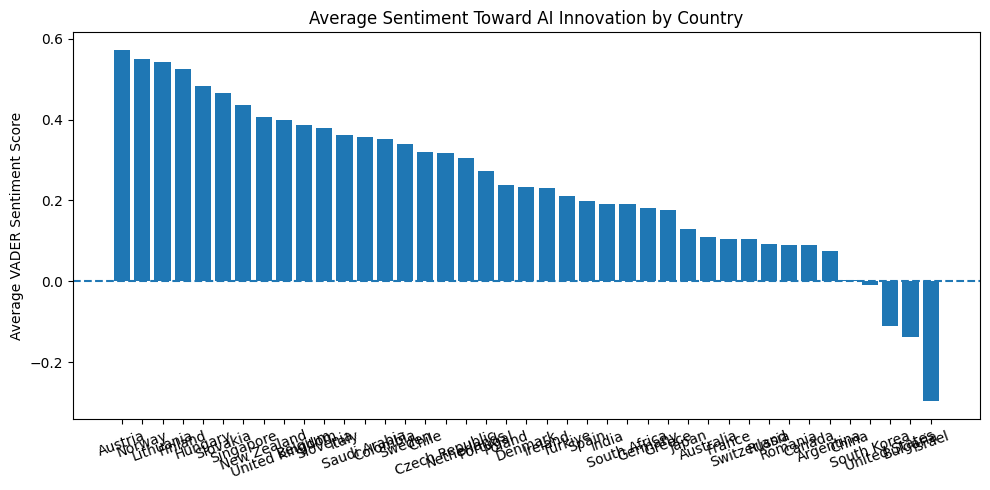

In [ ]:
plt.figure(figsize=(10, 5))
plt.bar(country_summary["country"], country_summary["avg_sentiment"])
plt.axhline(0, linestyle="--")
plt.title("Average Sentiment Toward AI Innovation by Country")
plt.ylabel("Average VADER Sentiment Score")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

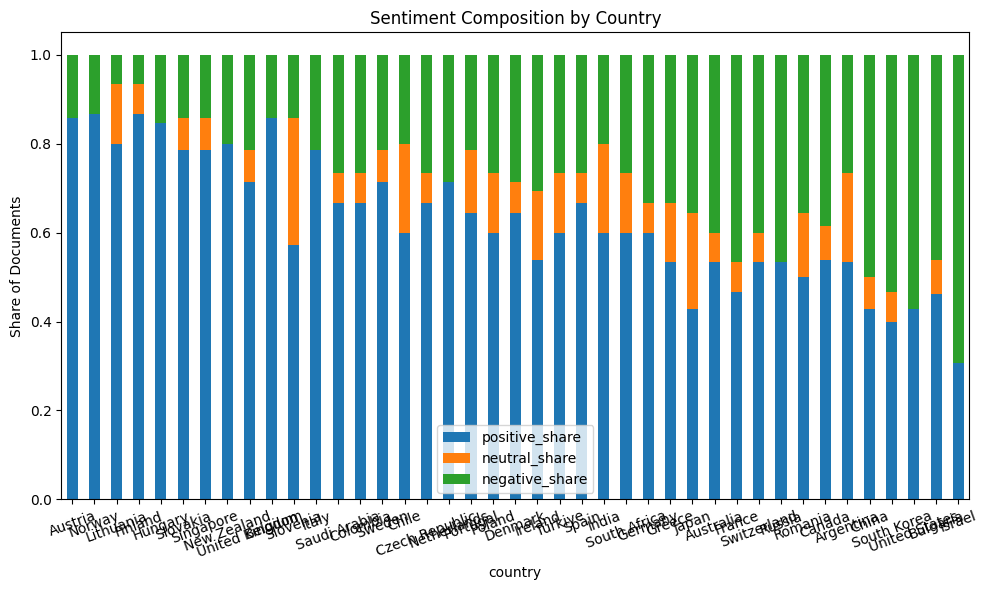

In [ ]:
plot_df = country_summary.set_index("country")[["positive_share", "neutral_share", "negative_share"]]

plot_df.plot(kind="bar", stacked=True, figsize=(10, 6))
plt.title("Sentiment Composition by Country")
plt.ylabel("Share of Documents")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

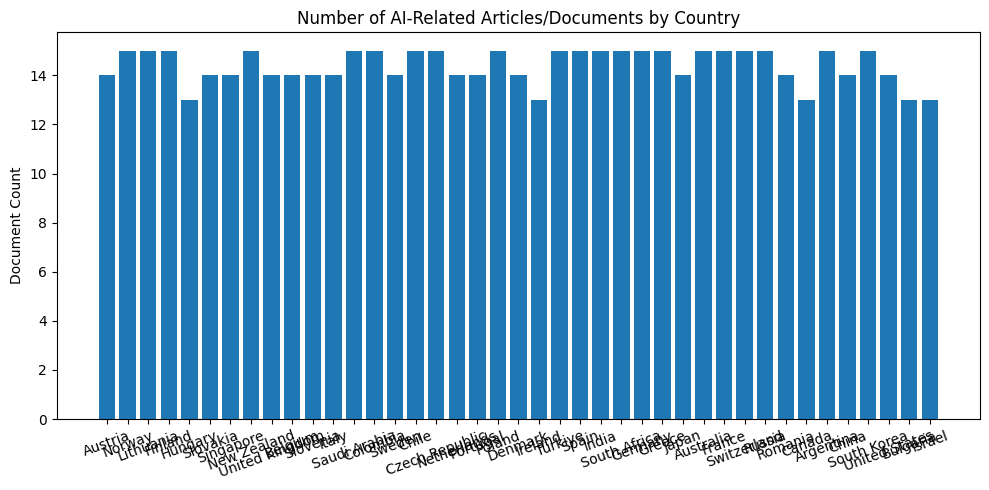

In [ ]:
plt.figure(figsize=(10, 5))
plt.bar(country_summary["country"], country_summary["n_documents"])
plt.title("Number of AI-Related Articles/Documents by Country")
plt.ylabel("Document Count")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [ ]:
df.to_csv("ai_sentiment_all_documents.csv", index=False)
country_summary.to_csv("ai_sentiment_country_summary.csv", index=False)
source_country_summary.to_csv("ai_sentiment_source_country_summary.csv", index=False)

print("Files saved:")
print("1. ai_sentiment_all_documents.csv")
print("2. ai_sentiment_country_summary.csv")
print("3. ai_sentiment_source_country_summary.csv")

Files saved:
1. ai_sentiment_all_documents.csv
2. ai_sentiment_country_summary.csv
3. ai_sentiment_source_country_summary.csv


In [ ]:
print("Country ranking by average sentiment:")
print(country_summary[["country", "avg_sentiment", "n_documents"]])

Country ranking by average sentiment:
           country  avg_sentiment  n_documents
2          Austria       0.572371           14
24          Norway       0.550340           15
21       Lithuania       0.542107           15
11         Finland       0.524080           15
15         Hungary       0.482115           13
31        Slovakia       0.466886           14
30       Singapore       0.436729           14
23     New Zealand       0.405320           15
39  United Kingdom       0.398979           14
3          Belgium       0.387629           14
32        Slovenia       0.378086           14
19           Italy       0.361514           14
29    Saudi Arabia       0.357807           15
8         Colombia       0.352580           15
36          Sweden       0.339971           14
6            Chile       0.318927           15
9   Czech Republic       0.318387           15
22     Netherlands       0.305971           14
26        Portugal       0.272650           14
25          Poland    